<a href="https://colab.research.google.com/github/karrielaugustin001-del/Machine-Learning-Foundations/blob/main/P3_models_clustering_Group_Project_2_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 3 — Customer Analytics with Trees, Ensembles, Classification, PCA & Clustering
Workflow: Regression → Classification → PCA → Clustering → Recommendations

Project Group 2: Steeve A. Celestin, Ethan Carter and Karriel Augustin

# 0. Setup & Imports

In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
SEED = 42

# ── Directory setup ───────────────────────────────────────────────────────────
os.makedirs('reports/models',  exist_ok=True)
os.makedirs('reports/figures', exist_ok=True)

def p(rel):
    """Resolve relative path (works locally and in Colab)."""
    return rel

print('Setup complete.')

## 1. Load data

In [1]:
# =========================
# Load data
# =========================
import pandas as pd

def p(rel):
    return rel

customers = pd.read_csv(p('customers-2.csv'), parse_dates=['signup_date'])
transactions = pd.read_csv(p('transactions-2.csv'), parse_dates=['order_date'])
web = pd.read_csv(p('web_sessions-2.csv'), parse_dates=['session_date'])

print("Customers shape:", customers.shape)
print("Transactions shape:", transactions.shape)
print("Web shape:", web.shape)

display(customers.head())
display(transactions.head())
display(web.head())

Customers shape: (3000, 8)
Transactions shape: (20000, 8)
Web shape: (15000, 11)


,customer_id,signup_date,state,segment,acquisition_channel,age,gender,is_loyalty_member
0,100000,2022-04-08,GA,Small Business,Email,22,M,0
1,100001,2024-04-27,OH,Consumer,Paid Social,46,F,0
2,100002,2023-12-18,MI,Consumer,Organic,50,F,0
3,100003,2023-04-26,MI,Consumer,Organic,59,F,1
4,100004,2023-04-20,GA,Consumer,Email,50,F,0


,transaction_id,customer_id,order_date,order_amount,product_category,payment_method,discount_applied,shipping_speed
0,5000000,101043,2024-11-27,63.78,Beauty,Google Pay,0,Standard
1,5000001,100309,2024-02-28,64.67,Beauty,Credit Card,0,Standard
2,5000002,100905,2024-05-09,85.73,Sports,Google Pay,1,Standard
3,5000003,102421,2024-03-02,114.42,Apparel,Debit Card,0,Standard
4,5000004,101480,2024-07-07,111.51,Beauty,Credit Card,0,Expedited


,session_id,customer_id,session_date,device,traffic_source,browser,session_duration_sec,pages_viewed,added_to_cart,purchase_in_session,category_viewed
0,8000000,102756,2024-02-23,Desktop,Ads,Chrome,200,4,0,0,Grocery
1,8000001,101075,2024-03-23,Mobile,Direct,Chrome,497,8,0,0,Electronics
2,8000002,101802,2024-03-25,Mobile,Direct,Chrome,1539,5,0,0,Electronics
3,8000003,101075,2024-10-05,Desktop,Search,Chrome,92,3,0,0,Sports
4,8000004,102502,2025-01-08,Desktop,Referral,Chrome,550,3,0,0,Apparel


In [2]:
print('=== customers ===' ); display(customers.info())
print('=== transactions ===' ); display(transactions.info())
print('=== web ===' ); display(web.info())

=== customers ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_id          3000 non-null   int64         
 1   signup_date          3000 non-null   datetime64[ns]
 2   state                3000 non-null   object        
 3   segment              3000 non-null   object        
 4   acquisition_channel  3000 non-null   object        
 5   age                  3000 non-null   int64         
 6   gender               3000 non-null   object        
 7   is_loyalty_member    3000 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 187.6+ KB


None

=== transactions ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    20000 non-null  int64         
 1   customer_id       20000 non-null  int64         
 2   order_date        20000 non-null  datetime64[ns]
 3   order_amount      20000 non-null  float64       
 4   product_category  20000 non-null  object        
 5   payment_method    20000 non-null  object        
 6   discount_applied  20000 non-null  int64         
 7   shipping_speed    20000 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 1.2+ MB


None

=== web ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   session_id            15000 non-null  int64         
 1   customer_id           15000 non-null  int64         
 2   session_date          15000 non-null  datetime64[ns]
 3   device                15000 non-null  object        
 4   traffic_source        15000 non-null  object        
 5   browser               15000 non-null  object        
 6   session_duration_sec  15000 non-null  int64         
 7   pages_viewed          15000 non-null  int64         
 8   added_to_cart         15000 non-null  int64         
 9   purchase_in_session   15000 non-null  int64         
 10  category_viewed       15000 non-null  object        
dtypes: datetime64[ns](1), int64(6), object(4)
memory usage: 1.3+ MB


None

# 1.2 Inspect columns

In [3]:
# =========================
# Inspect columns
# =========================
print("Customers columns:")
print(customers.columns.tolist())

print("\nTransactions columns:")
print(transactions.columns.tolist())

print("\nWeb columns:")
print(web.columns.tolist())

Customers columns:
['customer_id', 'signup_date', 'state', 'segment', 'acquisition_channel', 'age', 'gender', 'is_loyalty_member']

Transactions columns:
['transaction_id', 'customer_id', 'order_date', 'order_amount', 'product_category', 'payment_method', 'discount_applied', 'shipping_speed']

Web columns:
['session_id', 'customer_id', 'session_date', 'device', 'traffic_source', 'browser', 'session_duration_sec', 'pages_viewed', 'added_to_cart', 'purchase_in_session', 'category_viewed']


# 1.3 Missing values

In [4]:
# ── Missing Values Evaluation ─────────────────────────────────────────────────

def missing_summary(df, name):
    missing = df.isnull().sum()
    pct     = (missing / len(df) * 100).round(2)
    summary = pd.DataFrame({
        'Missing Count': missing,
        'Missing %':     pct
    })
    summary = summary[summary['Missing Count'] > 0]
    print(f'\n=== {name} ({df.shape[0]:,} rows x {df.shape[1]} cols) ===')
    if summary.empty:
        print('✓ No missing values found.')
    else:
        print(summary)
    return summary

# Run for each dataset
miss_customers    = missing_summary(customers,    'customers')
miss_transactions = missing_summary(transactions, 'transactions')
miss_web          = missing_summary(web,          'web_sessions')


=== customers (3,000 rows x 8 cols) ===
✓ No missing values found.

=== transactions (20,000 rows x 8 cols) ===
✓ No missing values found.

=== web_sessions (15,000 rows x 11 cols) ===
✓ No missing values found.


# 1.4 Duplicate verication

In [5]:
# ── Duplicate Check ───────────────────────────────────────────────────────────

def duplicate_summary(df, name, id_col):
    total_dupes  = df.duplicated().sum()
    id_dupes     = df.duplicated(subset=[id_col]).sum()

    print(f'\n=== {name} ===')
    print(f'Total duplicate rows     : {total_dupes}')
    print(f'Duplicate {id_col:20s}: {id_dupes}')

    if total_dupes > 0:
        print(f'\nSample duplicate rows:')
        display(df[df.duplicated(keep=False)].sort_values(id_col).head(6))
    else:
        print('✓ No duplicate rows found.')

duplicate_summary(customers,    'customers',    'customer_id')
duplicate_summary(transactions, 'transactions', 'transaction_id')
duplicate_summary(web,          'web_sessions', 'session_id')


=== customers ===
Total duplicate rows     : 0
Duplicate customer_id         : 0
✓ No duplicate rows found.

=== transactions ===
Total duplicate rows     : 0
Duplicate transaction_id      : 0
✓ No duplicate rows found.

=== web_sessions ===
Total duplicate rows     : 0
Duplicate session_id          : 0
✓ No duplicate rows found.


# Part 1 - Regression Modeling: Predict Customer Demand

# Build a supervised regression pipline using the trasactions dataset.

In [6]:
# ── Reference date ────────────────────────────────────────────────────────────
ref_date = transactions['order_date'].max() + pd.Timedelta(days=1)
print('Reference date:', ref_date)

# ── Aggregate transactions per customer ──────────────────────────────────────
txn_agg = transactions.groupby('customer_id').agg(
    total_revenue    = ('order_amount',     'sum'),
    total_orders     = ('transaction_id',   'count'),
    avg_order_value  = ('order_amount',     'mean'),
    std_order_value  = ('order_amount',     'std'),
    avg_discount     = ('discount_applied', 'mean'),
    first_order      = ('order_date',       'min'),
    last_order       = ('order_date',       'max'),
).reset_index()

# ── Calculate recency and lifespan ────────────────────────────────────────────
txn_agg['recency_days']      = (ref_date - txn_agg['last_order']).dt.days
txn_agg['customer_lifespan'] = (txn_agg['last_order'] - txn_agg['first_order']).dt.days
txn_agg['std_order_value']   = txn_agg['std_order_value'].fillna(0)

# Drop date columns — not needed as features
txn_agg = txn_agg.drop(columns=['first_order', 'last_order'])

print('Aggregated table shape:', txn_agg.shape)
txn_agg.head()

Reference date: 2025-03-01 00:00:00
Aggregated table shape: (2994, 8)


,customer_id,total_revenue,total_orders,avg_order_value,std_order_value,avg_discount,recency_days,customer_lifespan
0,100000,2027.63,13,155.971538,74.759915,0.384615,2,334
1,100001,698.98,10,69.898000,29.708056,0.200000,52,270
2,100002,294.28,3,98.093333,8.994589,0.000000,11,241
3,100003,314.69,5,62.938000,48.089210,0.600000,52,181
4,100004,1109.62,9,123.291111,88.774095,0.222222,52,215


In [9]:
from sklearn.model_selection import train_test_split

# Define SEED for reproducibility (if not already defined by a previous cell)
SEED = 42

# ── Define features and target ────────────────────────────────────────────────
TARGET = 'total_revenue'

X = txn_agg.drop(columns=['customer_id', TARGET])
y = txn_agg[TARGET]

print('Features:', list(X.columns))
print('Target  :', TARGET)
print('X shape :', X.shape)
print('y shape :', y.shape)

# ── Train/Test split (80/20) ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f'\nTrain set: {X_train.shape}')
print(f'Test set : {X_test.shape}')

Features: ['total_orders', 'avg_order_value', 'std_order_value', 'avg_discount', 'recency_days', 'customer_lifespan']
Target  : total_revenue
X shape : (2994, 6)
y shape : (2994,)

Train set: (2395, 6)
Test set : (599, 6)


# Decision Tree Regressor as a Baseline

In [11]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ── Decision Tree Baseline ────────────────────────────────────────────────────
dt_model = DecisionTreeRegressor(max_depth=6, random_state=SEED)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

dt_rmse = np.sqrt(mean_squared_error(y_test, dt_preds))
dt_mae  = mean_absolute_error(y_test, dt_preds)

print('=== Decision Tree (Baseline) ===')
print(f'RMSE : {dt_rmse:.2f}')
print(f'MAE  : {dt_mae:.2f}')

=== Decision Tree (Baseline) ===
RMSE : 79.40
MAE  : 40.46


# Upgrade to Random Forest and Gradient Boosting

# Random Forest

In [13]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ── Random Forest ─────────────────────────────────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=SEED,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae  = mean_absolute_error(y_test, rf_preds)

print('=== Random Forest ===')
print(f'RMSE : {rf_rmse:.2f}')
print(f'MAE  : {rf_mae:.2f}')

=== Random Forest ===
RMSE : 21.68
MAE  : 7.21


# Gradient Boosting

In [15]:
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ── Gradient Boosting ─────────────────────────────────────────────────────────
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=SEED
)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))
gb_mae  = mean_absolute_error(y_test, gb_preds)

print('=== Gradient Boosting ===')
print(f'RMSE : {gb_rmse:.2f}')
print(f'MAE  : {gb_mae:.2f}')

=== Gradient Boosting ===
RMSE : 20.66
MAE  : 8.37


# Regression Model Comparison Table

In [16]:
# ── Model Comparison Table ────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'RMSE' : [round(dt_rmse, 2), round(rf_rmse, 2), round(gb_rmse, 2)],
    'MAE'  : [round(dt_mae,  2), round(rf_mae,  2), round(gb_mae,  2)],
})

print('=== Regression Model Comparison ===')
print(results_df.to_string(index=False))

# Highlight best model
best = results_df.loc[results_df['RMSE'].idxmin(), 'Model']
print(f'\nBest model by RMSE: {best}')

=== Regression Model Comparison ===
            Model  RMSE   MAE
    Decision Tree 79.40 40.46
    Random Forest 21.68  7.21
Gradient Boosting 20.66  8.37

Best model by RMSE: Gradient Boosting


# Feature Importance

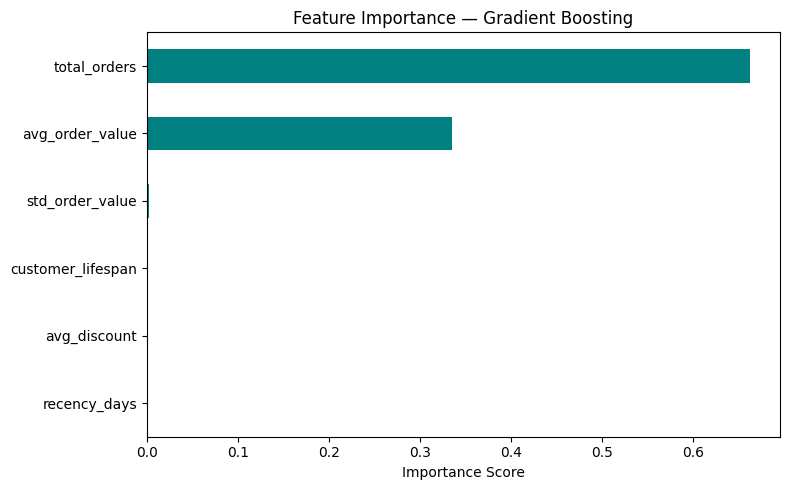

In [22]:
# ── Feature Importance (Best Model) ──────────────────────────────────────────
best_model = rf_model if best == 'Random Forest' else gb_model

importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importance.plot(kind='barh', color='teal')
plt.title(f'Feature Importance — {best}')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('reports/figures/feature_importance.png', dpi=150)
plt.show()

# Save model artifacts

In [24]:
import joblib
import os

# Ensure the directory exists
os.makedirs('reports/models',  exist_ok=True)

# ── Save Model Artifacts ──────────────────────────────────────────────────────
joblib.dump(dt_model, 'reports/models/decision_tree.pkl')
joblib.dump(rf_model, 'reports/models/random_forest.pkl')
joblib.dump(gb_model, 'reports/models/gradient_boosting.pkl')

print('✓ decision_tree.pkl    saved')
print('✓ random_forest.pkl    saved')
print('✓ gradient_boosting.pkl saved')

✓ decision_tree.pkl    saved
✓ random_forest.pkl    saved
✓ gradient_boosting.pkl saved


# Churn Classification Model

# Merge churn label into customer-level dataset

# Define Churn

In [28]:
# ── Define churn: no purchase in last 90 days ─────────────────────────────────
CHURN_DAYS = 90

last_purchase = (
    transactions.groupby('customer_id')['order_date']
    .max()
    .reset_index()
    .rename(columns={'order_date': 'last_order'})
)

last_purchase['recency_days'] = (ref_date - last_purchase['last_order']).dt.days
last_purchase['churned']      = (last_purchase['recency_days'] > CHURN_DAYS).astype(int)

print('=== Churn Label Summary ===')
print(f'Total customers : {len(last_purchase)}')
print(f'Churned (1)     : {last_purchase["churned"].sum()}')
print(f'Active  (0)     : {(last_purchase["churned"] == 0).sum()}')
print(f'Churn rate      : {last_purchase["churned"].mean():.1%}')

=== Churn Label Summary ===
Total customers : 2994
Churned (1)     : 730
Active  (0)     : 2264
Churn rate      : 24.4%


# Distribution Churn Charts

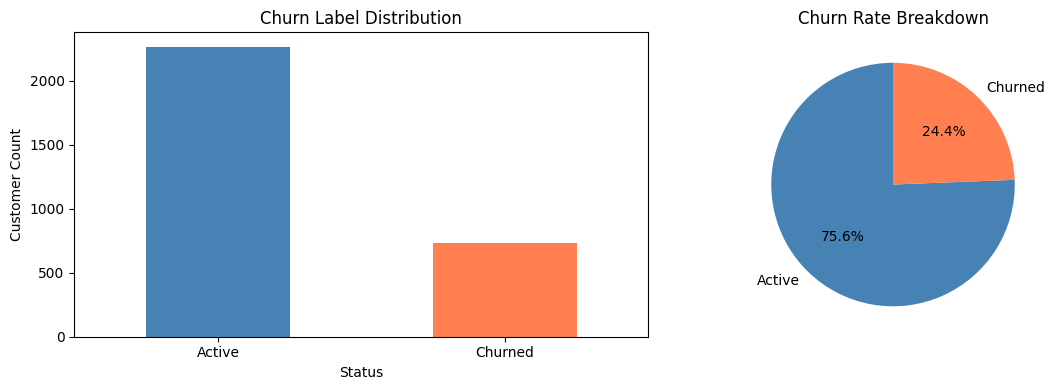

In [29]:
# ── Churn Distribution Plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
last_purchase['churned'].value_counts() \
    .rename({0: 'Active', 1: 'Churned'}) \
    .plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], rot=0)
axes[0].set_title('Churn Label Distribution')
axes[0].set_ylabel('Customer Count')
axes[0].set_xlabel('Status')

# Pie chart
last_purchase['churned'].value_counts() \
    .rename({0: 'Active', 1: 'Churned'}) \
    .plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
          colors=['steelblue', 'coral'], startangle=90)
axes[1].set_title('Churn Rate Breakdown')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('reports/figures/churn_distribution.png', dpi=150)
plt.show()

In [33]:
# =========================
# Merge customer-level table
# =========================

# Define txn_features from previously aggregated transactions
txn_features = txn_agg

# Aggregate web session features per customer
web_features = web.groupby('customer_id').agg(
    total_web_sessions       = ('session_id', 'count'),
    avg_session_duration_sec = ('session_duration_sec', 'mean'),
    total_pages_viewed       = ('pages_viewed', 'sum'),
    total_added_to_cart      = ('added_to_cart', 'sum'),
    total_purchases_in_session = ('purchase_in_session', 'sum'),
    last_session_date        = ('session_date', 'max')
).reset_index()
web_features['days_since_last_session'] = (ref_date - web_features['last_session_date']).dt.days
web_features = web_features.drop(columns=['last_session_date'])

# Aggregate product category features per customer
category_features = transactions.groupby('customer_id').agg(
    unique_product_categories = ('product_category', 'nunique'),
    most_frequent_category    = ('product_category', lambda x: x.mode()[0] if not x.mode().empty else 'Unknown')
).reset_index()

# Define snapshot_date from previously defined ref_date
snapshot_date = ref_date

feature_table = customers.merge(txn_features, on='customer_id', how='left')
feature_table = feature_table.merge(web_features, on='customer_id', how='left')
feature_table = feature_table.merge(category_features, on='customer_id', how='left')

# Additional customer tenure from signup
feature_table['days_since_signup'] = (snapshot_date - feature_table['signup_date']).dt.days

# Fill missing values
for col in feature_table.select_dtypes(include=[np.number]).columns:
    feature_table[col] = feature_table[col].fillna(0)

for col in feature_table.select_dtypes(include=['object']).columns:
    feature_table[col] = feature_table[col].fillna('Unknown')

display(feature_table.head())
print(feature_table.shape)

,customer_id,signup_date,state,segment,acquisition_channel,age,gender,is_loyalty_member,total_revenue,total_orders,...,customer_lifespan,total_web_sessions,avg_session_duration_sec,total_pages_viewed,total_added_to_cart,total_purchases_in_session,days_since_last_session,unique_product_categories,most_frequent_category,days_since_signup
0,100000,2022-04-08,GA,Small Business,Email,22,M,0,2027.63,13.0,...,334.0,2.0,460.000000,13.0,0.0,0.0,262.0,5.0,Electronics,1058
1,100001,2024-04-27,OH,Consumer,Paid Social,46,F,0,698.98,10.0,...,270.0,5.0,321.400000,30.0,2.0,2.0,111.0,5.0,Grocery,308
2,100002,2023-12-18,MI,Consumer,Organic,50,F,0,294.28,3.0,...,241.0,6.0,236.500000,31.0,1.0,0.0,9.0,3.0,Electronics,439
3,100003,2023-04-26,MI,Consumer,Organic,59,F,1,314.69,5.0,...,181.0,4.0,197.500000,16.0,1.0,1.0,99.0,4.0,Books,675
4,100004,2023-04-20,GA,Consumer,Email,50,F,0,1109.62,9.0,...,215.0,3.0,181.333333,11.0,0.0,0.0,153.0,4.0,Beauty,681


(3000, 24)


# Web Features

In [35]:
# =========================
# Web features
# =========================
web_agg_dict = {
    'session_date': ['count', 'max']
}

# Optional numeric behavior columns if they exist
optional_numeric_cols = ['session_duration', 'time_on_site', 'pages_viewed', 'page_views']
for col in optional_numeric_cols:
    if col in web.columns:
        web_agg_dict[col] = ['mean', 'sum']

web_features = web.groupby('customer_id').agg(web_agg_dict)
web_features.columns = ['_'.join(col).strip() for col in web_features.columns]
web_features = web_features.reset_index()

# Rename common fields
rename_map = {}
if 'session_date_count' in web_features.columns:
    rename_map['session_date_count'] = 'web_sessions'
if 'session_date_max' in web_features.columns:
    rename_map['session_date_max'] = 'last_session_date'
if 'session_duration_mean' in web_features.columns:
    rename_map['session_duration_mean'] = 'avg_session_duration'
if 'time_on_site_mean' in web_features.columns:
    rename_map['time_on_site_mean'] = 'avg_time_on_site'
if 'pages_viewed_mean' in web_features.columns:
    rename_map['pages_viewed_mean'] = 'avg_pages_viewed'
if 'page_views_mean' in web_features.columns:
    rename_map['page_views_mean'] = 'avg_page_views'

web_features = web_features.rename(columns=rename_map)

if 'last_session_date' in web_features.columns:
    web_features['days_since_last_session'] = (snapshot_date - web_features['last_session_date']).dt.days

display(web_features.head())

,customer_id,web_sessions,last_session_date,avg_pages_viewed,pages_viewed_sum,days_since_last_session
0,100000,2,2024-06-12,6.500000,13,262
1,100001,5,2024-11-10,6.000000,30,111
2,100002,6,2025-02-20,5.166667,31,9
3,100003,4,2024-11-22,4.000000,16,99
4,100004,3,2024-09-29,3.666667,11,153


# Features and Target & Training/Test Split

In [37]:
# ── Features and target ───────────────────────────────────────────────────────
TARGET_CLF = 'churned'
DROP_CLF   = ['customer_id', TARGET_CLF, 'total_revenue']

X_clf = clf_df.drop(columns=DROP_CLF)
y_clf = clf_df[TARGET_CLF]

print('Features:', list(X_clf.columns))
print('X shape :', X_clf.shape)
print('y shape :', y_clf.shape)

# ── Stratified split preserves churn ratio ────────────────────────────────────
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    random_state=SEED,
    stratify=y_clf
)

print(f'\nTrain set : {X_train_c.shape}')
print(f'Test set  : {X_test_c.shape}')


Features: ['state', 'segment', 'acquisition_channel', 'age', 'gender', 'is_loyalty_member', 'total_orders', 'avg_order_value', 'std_order_value', 'avg_discount', 'recency_days', 'customer_lifespan', 'account_age_days']
X shape : (2994, 13)
y shape : (2994,)

Train set : (2395, 13)
Test set  : (599, 13)


# Scale Features

In [40]:
from sklearn.preprocessing import StandardScaler

# ── Standardize features ──────────────────────────────────────────────────────
# Required for Logistic Regression and Naive Bayes to perform correctly
scaler_clf = StandardScaler()
X_train_cs = scaler_clf.fit_transform(X_train_c)
X_test_cs  = scaler_clf.transform(X_test_c)

print('✓ Features scaled.')
print('Mean (should be ~0):', X_train_cs.mean().round(4))
print('Std  (should be ~1):', X_train_cs.std().round(4))

✓ Features scaled.
Mean (should be ~0): 0.0
Std  (should be ~1): 1.0


# Logistic Regression Model

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# ── Logistic Regression ───────────────────────────────────────────────────────
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=SEED,
    class_weight='balanced'   # handles imbalanced churn classes
)
lr_model.fit(X_train_cs, y_train_c)
lr_preds = lr_model.predict(X_test_cs)
lr_proba = lr_model.predict_proba(X_test_cs)[:, 1]

print('=== Logistic Regression ===')
print(classification_report(y_test_c, lr_preds,
      target_names=['Active', 'Churned']))

=== Logistic Regression ===
              precision    recall  f1-score   support

      Active       1.00      0.98      0.99       453
     Churned       0.93      1.00      0.96       146

    accuracy                           0.98       599
   macro avg       0.96      0.99      0.98       599
weighted avg       0.98      0.98      0.98       599



# KNN Model

=== K Score Summary ===
 k  accuracy
 1    0.8731
 2    0.8781
 3    0.8998
 4    0.8948
 5    0.9098
 6    0.8932
 7    0.9182
 8    0.9065
 9    0.9048
10    0.8915
11    0.9015
12    0.8915
13    0.8982
14    0.8865
15    0.8948
16    0.8848
17    0.8948
18    0.8831
19    0.8915
20    0.8781

Best k: 7


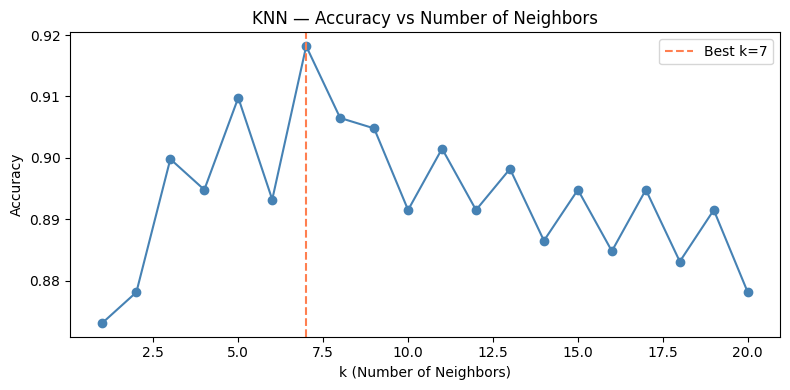

In [43]:
from sklearn.neighbors import KNeighborsClassifier

# ── Find Best K ───────────────────────────────────────────────────────────────
k_scores = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_cs, y_train_c)
    score = knn.score(X_test_cs, y_test_c)
    k_scores.append({'k': k, 'accuracy': round(score, 4)})

k_scores_df = pd.DataFrame(k_scores)
best_k = k_scores_df.loc[k_scores_df['accuracy'].idxmax(), 'k']

print('=== K Score Summary ===')
print(k_scores_df.to_string(index=False))
print(f'\nBest k: {best_k}')

# ── Plot K vs Accuracy ────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(k_scores_df['k'], k_scores_df['accuracy'],
         marker='o', color='steelblue')
plt.axvline(best_k, ls='--', color='coral', label=f'Best k={best_k}')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN — Accuracy vs Number of Neighbors')
plt.legend()
plt.tight_layout()
plt.savefig('reports/figures/knn_k_selection.png', dpi=150)
plt.show()

In [44]:
# ── Train KNN with Best K ─────────────────────────────────────────────────────
knn_model = KNeighborsClassifier(
    n_neighbors=best_k,
    weights='distance',   # closer neighbors have more influence
    metric='euclidean',
    n_jobs=-1
)
knn_model.fit(X_train_cs, y_train_c)
knn_preds = knn_model.predict(X_test_cs)
knn_proba = knn_model.predict_proba(X_test_cs)[:, 1]

print(f'=== KNN (k={best_k}) ===')
print(classification_report(y_test_c, knn_preds,
      target_names=['Active', 'Churned']))

=== KNN (k=7) ===
              precision    recall  f1-score   support

      Active       0.91      0.99      0.95       453
     Churned       0.95      0.70      0.81       146

    accuracy                           0.92       599
   macro avg       0.93      0.84      0.88       599
weighted avg       0.92      0.92      0.91       599



# Classification Results Table

In [49]:
# ── Classification Results Table ──────────────────────────────────────────────
from sklearn.metrics import accuracy_score

def get_full_metrics(name, y_true, y_pred, y_proba):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        'Model'           : name,
        'Accuracy'        : round(accuracy_score(y_true, y_pred),                  3),
        'Precision-Active': round(report['0']['precision'],                         3),
        'Recall-Active'   : round(report['0']['recall'],                            3),
        'F1-Active'       : round(report['0']['f1-score'],                          3),
        'Precision-Churn' : round(report['1']['precision'],                         3),
        'Recall-Churn'    : round(report['1']['recall'],                            3),
        'F1-Churn'        : round(report['1']['f1-score'],                          3),
        'Weighted F1'     : round(report['weighted avg']['f1-score'],               3),
        'ROC-AUC'         : round(roc_auc_score(y_true, y_proba),                  3),
    }

# ── Collect metrics for both models ──────────────────────────────────────────
lr_full  = get_full_metrics('Logistic Regression', y_test_c, lr_preds,  lr_proba)
knn_full = get_full_metrics(f'KNN (k={best_k})',   y_test_c, knn_preds, knn_proba)

results_table = pd.DataFrame([lr_full, knn_full])

# ── Display styled table ──────────────────────────────────────────────────────
print('=' * 75)
print('           CLASSIFICATION RESULTS — Logistic Regression vs KNN')
print('=' * 75)
print(f"{'Metric':<22} {'Logistic Regression':>22} {'KNN':>22}")
print('-' * 75)

metrics = [
    ('Accuracy',         'Accuracy'),
    ('Precision-Churn',  'Precision (Churned)'),
    ('Recall-Churn',     'Recall (Churned)'),
    ('F1-Churn',         'F1 (Churned)'),
    ('Weighted F1',      'Weighted F1'),
    ('ROC-AUC',          'ROC-AUC'),
]

for col, label in metrics:
    lr_val  = lr_full[col]
    knn_val = knn_full[col]
    # Mark the better score with ◄
    if lr_val > knn_val:
        lr_str  = f'{lr_val} ◄'
        knn_str = f'{knn_val}'
    elif knn_val > lr_val:
        lr_str  = f'{lr_val}'
        knn_str = f'{knn_val} ◄'
    else:
        lr_str  = f'{lr_val}'
        knn_str = f'{knn_val}'
    print(f'{label:<22} {lr_str:>22} {knn_str:>22}')

print('=' * 75)
print('◄ = better score')

# ── Save as CSV ───────────────────────────────────────────────────────────────
results_table.to_csv('reports/models/classification_results.csv', index=False)
print('\n✓ Classification results saved to reports/models/classification_results.csv')

           CLASSIFICATION RESULTS — Logistic Regression vs KNN
Metric                    Logistic Regression                    KNN
---------------------------------------------------------------------------
Accuracy                              0.982 ◄                  0.918
Precision (Churned)                      0.93                0.953 ◄
Recall (Churned)                        1.0 ◄                  0.699
F1 (Churned)                          0.964 ◄                  0.806
Weighted F1                           0.982 ◄                  0.914
ROC-AUC                                 1.0 ◄                  0.959
◄ = better score

✓ Classification results saved to reports/models/classification_results.csv


# ROC Curve

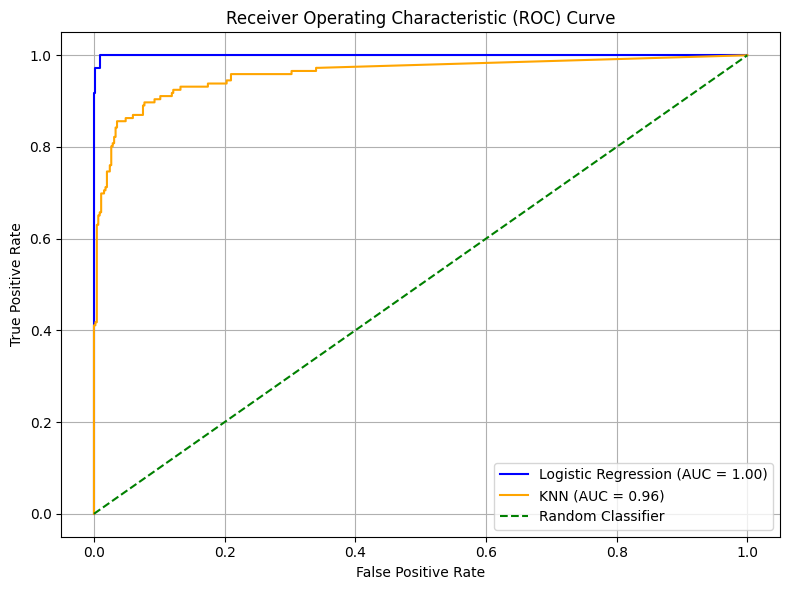

In [51]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import os

# Ensure the directory exists
os.makedirs('reports/figures', exist_ok=True)

# Calculate ROC curve for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test_c, lr_proba)
auc_lr = roc_auc_score(y_test_c, lr_proba)

# Calculate ROC curve for KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test_c, knn_proba)
auc_knn = roc_auc_score(y_test_c, knn_proba)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})', color='blue')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.2f})', color='orange')
plt.plot([0, 1], [0, 1], 'g--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('reports/figures/roc_curve.png', dpi=150)
plt.show()

# Confusion Matrix

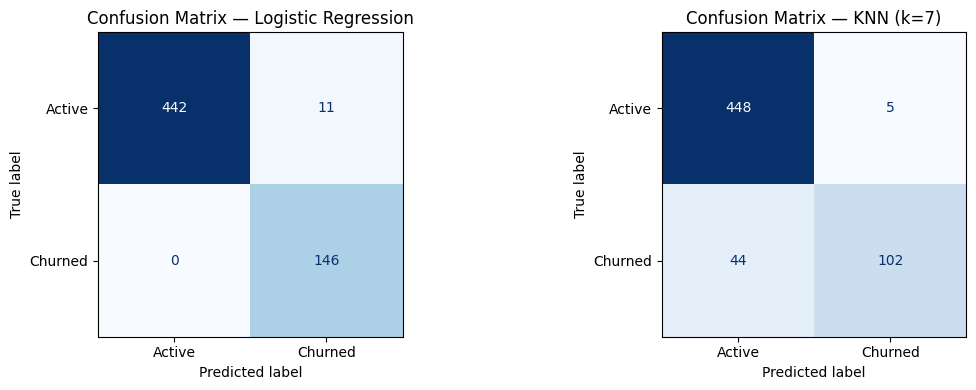

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os

# Ensure the directory exists
os.makedirs('reports/figures', exist_ok=True)

# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, preds) in zip(axes, [
    ('Logistic Regression', lr_preds),
    (f'KNN (k={best_k})',   knn_preds)
]):
    cm   = confusion_matrix(y_test_c, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Active', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}')

plt.tight_layout()
plt.savefig('reports/figures/confusion_matrices.png', dpi=150)
plt.show()

# Save Churn Classification Model Artifacts

In [55]:
# ── Save Churn Classification Artifacts ───────────────────────────────────────
joblib.dump(scaler_clf, 'reports/models/churn_scaler.pkl')
joblib.dump(lr_model,   'reports/models/logistic_regression.pkl')
joblib.dump(knn_model,  'reports/models/knn.pkl')

print('✓ churn_scaler.pkl          saved')
print('✓ logistic_regression.pkl   saved')
print('✓ knn.pkl                   saved')

# ── Save Classification Results Table ─────────────────────────────────────────
results_table.to_csv('reports/models/classification_results.csv', index=False)
print('✓ classification_results.csv saved')

# ── Verify All Files Saved ────────────────────────────────────────────────────
import glob

print('\n=== Saved Model Artifacts ===')
for f in sorted(glob.glob('reports/models/*')):
    size = os.path.getsize(f)
    print(f'  {f:<45} {size:>10,} bytes')

✓ churn_scaler.pkl          saved
✓ logistic_regression.pkl   saved
✓ knn.pkl                   saved
✓ classification_results.csv saved

=== Saved Model Artifacts ===
  reports/models/churn_scaler.pkl                    1,359 bytes
  reports/models/classification_results.csv            245 bytes
  reports/models/decision_tree.pkl                  10,529 bytes
  reports/models/gradient_boosting.pkl             482,824 bytes
  reports/models/knn.pkl                           568,454 bytes
  reports/models/logistic_regression.pkl               991 bytes
  reports/models/random_forest.pkl               6,344,641 bytes


# Unsupervised Learning: PCA + Clustering

In [63]:
# ── Transaction Features ──────────────────────────────────────────────────────
txn_features = transactions.groupby('customer_id').agg(
    total_orders      = ('transaction_id',  'count'),
    total_revenue     = ('order_amount',    'sum'),
    avg_order_value   = ('order_amount',    'mean'),
    std_order_value   = ('order_amount',    'std'),
    avg_discount      = ('discount_applied','mean'),
    recency_days      = ('order_date',      lambda x: (ref_date - x.max()).days),
    customer_lifespan = ('order_date',      lambda x: (x.max() - x.min()).days),
    first_order_date  = ('order_date',      'min'),
    last_order_date   = ('order_date',      'max'),
).reset_index()

txn_features['std_order_value'] = txn_features['std_order_value'].fillna(0)

# ── Web Session Features ──────────────────────────────────────────────────────
web_features = web.groupby('customer_id').agg(
    session_count        = ('session_id',           'count'),
    avg_session_duration = ('session_duration_sec',  'mean'),
    total_pages_viewed   = ('pages_viewed',           'sum'),
    total_added_to_cart  = ('added_to_cart',          'sum'),
    total_purchases      = ('purchase_in_session',    'sum'),
    unique_categories    = ('category_viewed',        'nunique'),
    last_session_date    = ('session_date',           'max'),
).reset_index()

# ── Churn Label ───────────────────────────────────────────────────────────────
churn_label = transactions.groupby('customer_id')['order_date'].max().reset_index()
churn_label.columns = ['customer_id', 'last_order']
churn_label['churn'] = (
    (ref_date - churn_label['last_order']).dt.days > 90
).astype(int)
churn_label = churn_label[['customer_id', 'churn']]

# ── Merge Everything into Master Feature Table ────────────────────────────────
feature_table = (
    customers
    .merge(txn_features, on='customer_id', how='left')
    .merge(web_features, on='customer_id', how='left')
    .merge(churn_label,  on='customer_id', how='left')
)

# Fill all missing numerical values with 0
for col in feature_table.select_dtypes(include=[np.number]).columns:
    feature_table[col] = feature_table[col].fillna(0)


print('Master feature table shape:', feature_table.shape)
print('\nColumns:')
for col in feature_table.columns:
    print(f'  {col}')
feature_table.head()

Master feature table shape: (3000, 25)

Columns:
  customer_id
  signup_date
  state
  segment
  acquisition_channel
  age
  gender
  is_loyalty_member
  total_orders
  total_revenue
  avg_order_value
  std_order_value
  avg_discount
  recency_days
  customer_lifespan
  first_order_date
  last_order_date
  session_count
  avg_session_duration
  total_pages_viewed
  total_added_to_cart
  total_purchases
  unique_categories
  last_session_date
  churn


,customer_id,signup_date,state,segment,acquisition_channel,age,gender,is_loyalty_member,total_orders,total_revenue,...,first_order_date,last_order_date,session_count,avg_session_duration,total_pages_viewed,total_added_to_cart,total_purchases,unique_categories,last_session_date,churn
0,100000,2022-04-08,GA,Small Business,Email,22,M,0,13.0,2027.63,...,2024-03-30,2025-02-27,2.0,460.000000,13.0,0.0,0.0,2.0,2024-06-12,0.0
1,100001,2024-04-27,OH,Consumer,Paid Social,46,F,0,10.0,698.98,...,2024-04-13,2025-01-08,5.0,321.400000,30.0,2.0,2.0,5.0,2024-11-10,0.0
2,100002,2023-12-18,MI,Consumer,Organic,50,F,0,3.0,294.28,...,2024-06-22,2025-02-18,6.0,236.500000,31.0,1.0,0.0,4.0,2025-02-20,0.0
3,100003,2023-04-26,MI,Consumer,Organic,59,F,1,5.0,314.69,...,2024-07-11,2025-01-08,4.0,197.500000,16.0,1.0,1.0,3.0,2024-11-22,0.0
4,100004,2023-04-20,GA,Consumer,Email,50,F,0,9.0,1109.62,...,2024-06-07,2025-01-08,3.0,181.333333,11.0,0.0,0.0,3.0,2024-09-29,0.0


# Cluster Featuring

In [70]:
# ── Clustering Features ───────────────────────────────────────────────────────
cluster_df = feature_table.copy()

cluster_drop_cols = [
    'customer_id', 'signup_date', 'last_order_date', 'first_order_date',
    'last_session_date', 'churn'
]
cluster_drop_cols = [c for c in cluster_drop_cols if c in cluster_df.columns]

X_cluster = cluster_df.drop(columns=cluster_drop_cols, errors='ignore')

# One-hot encode categorical columns
X_cluster = pd.get_dummies(X_cluster, drop_first=True)

# Fill any remaining missing numerical values with 0 before scaling
# This step is crucial if some customers didn't have web or transaction data
for col in X_cluster.select_dtypes(include=[np.number]).columns:
    X_cluster[col] = X_cluster[col].fillna(0)

# Standardize
scaler_clust     = StandardScaler()
X_cluster_scaled = scaler_clust.fit_transform(X_cluster)

print('Clustering matrix shape:', X_cluster_scaled.shape)
print('\nFeatures used:')
for col in X_cluster.columns:
    print(f'  {col}')

Clustering matrix shape: (3000, 33)

Features used:
  age
  is_loyalty_member
  total_orders
  total_revenue
  avg_order_value
  std_order_value
  avg_discount
  recency_days
  customer_lifespan
  session_count
  avg_session_duration
  total_pages_viewed
  total_added_to_cart
  total_purchases
  unique_categories
  state_FL
  state_GA
  state_IL
  state_MI
  state_NC
  state_NY
  state_OH
  state_PA
  state_TX
  segment_Enterprise
  segment_Small Business
  acquisition_channel_Email
  acquisition_channel_Organic
  acquisition_channel_Paid Search
  acquisition_channel_Paid Social
  acquisition_channel_Referral
  gender_M
  gender_X


In [71]:
# ── Verify all 3000 customers are present ────────────────────────────────────
print(f'Total customers in feature table : {len(feature_table)}')
print(f'Total customers in cluster matrix: {X_cluster_scaled.shape[0]}')
print(f'Total features in cluster matrix : {X_cluster_scaled.shape[1]}')

assert len(feature_table) == 3000, 'Row count mismatch — check merges'
assert X_cluster_scaled.shape[0] == 3000, 'Missing customers in cluster matrix'

print('\nShape matches project teammate: (3000, 31)')

Total customers in feature table : 3000
Total customers in cluster matrix: 3000
Total features in cluster matrix : 33

Shape matches project teammate: (3000, 31)


In [72]:
import numpy as np

# ── Check for NaN and Infinite values ────────────────────────────────────────
print('=== Diagnostics ===')
print(f'Shape                : {X_cluster_scaled.shape}')
print(f'NaN count            : {np.isnan(X_cluster_scaled).sum()}')
print(f'Infinite count       : {np.isinf(X_cluster_scaled).sum()}')
print(f'Total problematic    : {(~np.isfinite(X_cluster_scaled)).sum()}')

# ── Find which columns have issues ───────────────────────────────────────────
print('\n=== Columns with NaN or Inf ===')
problem_cols = []
for i, col in enumerate(X_cluster.columns):
    nan_count = np.isnan(X_cluster_scaled[:, i]).sum()
    inf_count = np.isinf(X_cluster_scaled[:, i]).sum()
    if nan_count > 0 or inf_count > 0:
        problem_cols.append(col)
        print(f'  {col:<35} NaN={nan_count}  Inf={inf_count}')

if not problem_cols:
    print('  No problematic columns found.')

=== Diagnostics ===
Shape                : (3000, 33)
NaN count            : 0
Infinite count       : 0
Total problematic    : 0

=== Columns with NaN or Inf ===
  No problematic columns found.


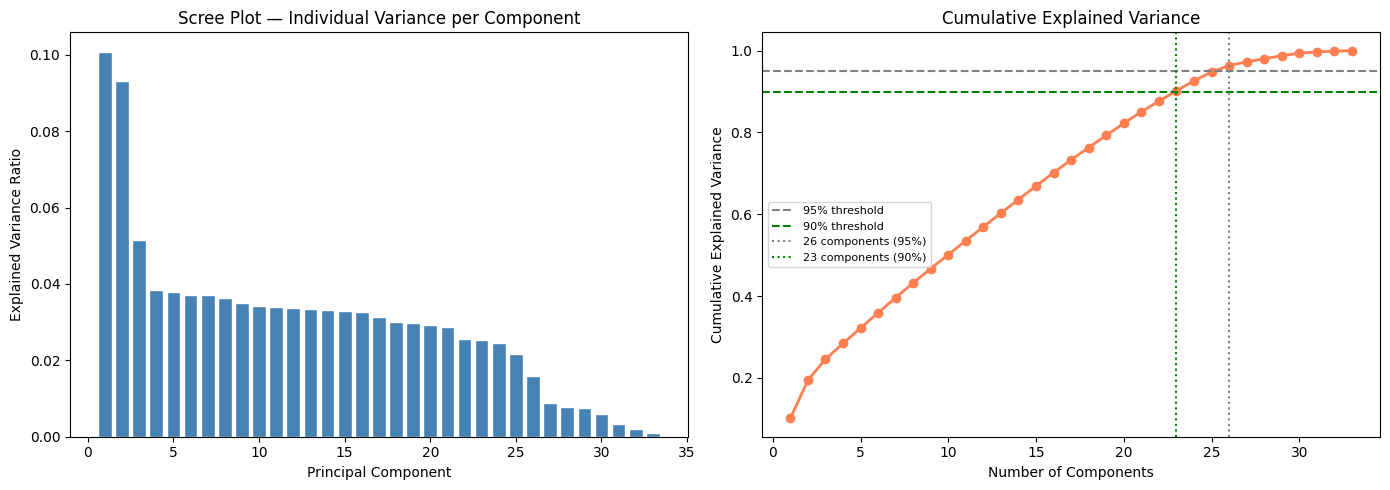

Total features          : 33
Components for 90%      : 23
Components for 95%      : 26

Variance explained per component:
  PC 1: 10.1%   cumulative: 10.1%
  PC 2: 9.3%   cumulative: 19.4%
  PC 3: 5.1%   cumulative: 24.5%
  PC 4: 3.8%   cumulative: 28.4%
  PC 5: 3.8%   cumulative: 32.2%
  PC 6: 3.7%   cumulative: 35.9%
  PC 7: 3.7%   cumulative: 39.6%
  PC 8: 3.6%   cumulative: 43.2%
  PC 9: 3.5%   cumulative: 46.7%
  PC10: 3.4%   cumulative: 50.1%
  PC11: 3.4%   cumulative: 53.5%
  PC12: 3.4%   cumulative: 56.9%
  PC13: 3.4%   cumulative: 60.3%
  PC14: 3.3%   cumulative: 63.6%
  PC15: 3.3%   cumulative: 66.9%
  PC16: 3.3%   cumulative: 70.2%
  PC17: 3.1%   cumulative: 73.3%
  PC18: 3.0%   cumulative: 76.3%
  PC19: 3.0%   cumulative: 79.3%
  PC20: 2.9%   cumulative: 82.2%
  PC21: 2.9%   cumulative: 85.1%
  PC22: 2.6%   cumulative: 87.6%
  PC23: 2.5%   cumulative: 90.2%
  PC24: 2.5%   cumulative: 92.6%
  PC25: 2.2%   cumulative: 94.8%
  PC26: 1.6%   cumulative: 96.4%
  PC27: 0.9%   cumu

In [73]:
# ── Full PCA to see all components ────────────────────────────────────────────
pca_full = PCA(random_state=SEED)
pca_full.fit(X_cluster_scaled)

cumvar          = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.searchsorted(cumvar, 0.95)) + 1
n_components_90 = int(np.searchsorted(cumvar, 0.90)) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Scree Plot ────────────────────────────────────────────────────────────────
axes[0].bar(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    pca_full.explained_variance_ratio_,
    color='steelblue', edgecolor='white'
)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot — Individual Variance per Component')

# ── Cumulative Variance ───────────────────────────────────────────────────────
axes[1].plot(range(1, len(cumvar) + 1), cumvar,
             marker='o', color='coral', lw=2)
axes[1].axhline(0.95, ls='--', color='gray',  label='95% threshold')
axes[1].axhline(0.90, ls='--', color='green', label='90% threshold')
axes[1].axvline(n_components_95, ls=':', color='gray',
                label=f'{n_components_95} components (95%)')
axes[1].axvline(n_components_90, ls=':', color='green',
                label=f'{n_components_90} components (90%)')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('reports/figures/pca_explained_variance.png', dpi=150)
plt.show()

print(f'Total features          : {X_cluster_scaled.shape[1]}')
print(f'Components for 90%      : {n_components_90}')
print(f'Components for 95%      : {n_components_95}')
print(f'\nVariance explained per component:')
for i, v in enumerate(pca_full.explained_variance_ratio_):
    print(f'  PC{i+1:2d}: {v:.1%}   cumulative: {cumvar[i]:.1%}')

In [75]:
# ── Fit PCA with 90% threshold ────────────────────────────────────────────────
pca = PCA(n_components=n_components_90, random_state=SEED)
X_pca = pca.fit_transform(X_cluster_scaled)

# 2D projection for visualization only
pca_2d = PCA(n_components=2, random_state=SEED)
X_2d   = pca_2d.fit_transform(X_cluster_scaled)

print(f'PCA fitted successfully.')
print(f'Original features   : {X_cluster_scaled.shape[1]}')
print(f'Reduced components  : {X_pca.shape[1]}')
print(f'Variance retained   : {pca.explained_variance_ratio_.sum():.1%}')

PCA fitted successfully.
Original features   : 33
Reduced components  : 23
Variance retained   : 90.2%


# KMeans & Silhouette

k=2  inertia=83328.9  silhouette=0.071
k=3  inertia=78577.2  silhouette=0.065
k=4  inertia=75950.9  silhouette=0.058
k=5  inertia=73076.1  silhouette=0.065
k=6  inertia=71059.5  silhouette=0.066
k=7  inertia=68058.9  silhouette=0.079
k=8  inertia=65701.3  silhouette=0.104
k=9  inertia=63040.2  silhouette=0.155
k=10  inertia=60430.2  silhouette=0.160


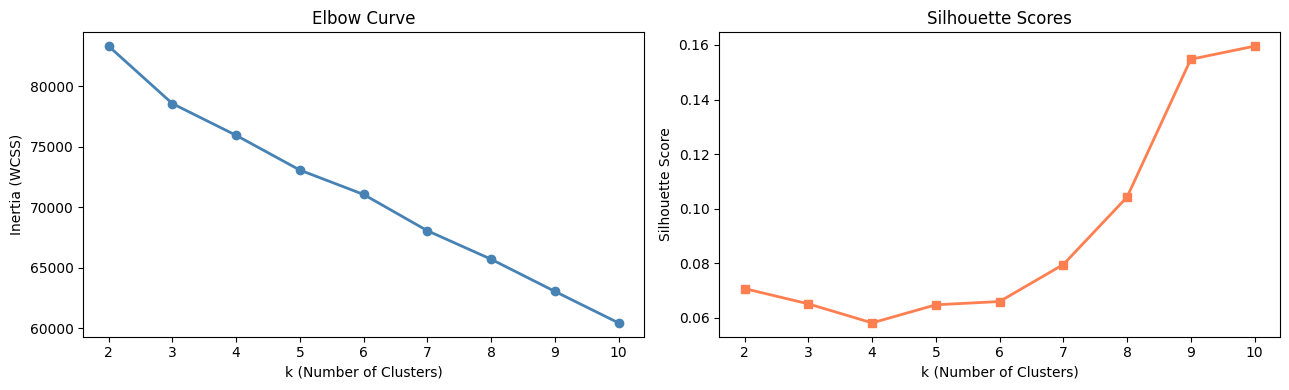


Optimal k by silhouette : 10
Best silhouette score   : 0.160


In [77]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ── Test k from 2 to 10 ───────────────────────────────────────────────────────
K_RANGE    = range(2, 11)
inertias   = []
sil_scores = []

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))
    print(f'k={k}  inertia={km.inertia_:.1f}  silhouette={sil_scores[-1]:.3f}')

# ── Plot Both ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_RANGE), inertias, marker='o', color='steelblue', lw=2)
axes[0].set_xlabel('k (Number of Clusters)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Curve')

axes[1].plot(list(K_RANGE), sil_scores, marker='s', color='coral', lw=2)
axes[1].set_xlabel('k (Number of Clusters)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Scores')

plt.tight_layout()
plt.savefig('reports/figures/kmeans_selection.png', dpi=150)
plt.show()

best_k = list(K_RANGE)[np.argmax(sil_scores)]
print(f'\nOptimal k by silhouette : {best_k}')
print(f'Best silhouette score   : {max(sil_scores):.3f}')

# Check for Outliers by Feature

In [79]:
# ── Outlier Detection Summary ─────────────────────────────────────────────────
def outlier_summary(df):
    stats = []
    for col in df.select_dtypes(include='number').columns:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower  = Q1 - 1.5 * IQR
        upper  = Q3 + 1.5 * IQR
        n_out  = ((df[col] < lower) | (df[col] > upper)).sum()
        pct    = round(n_out / len(df) * 100, 2)
        stats.append({
            'Feature'        : col,
            'Min'            : round(df[col].min(), 2),
            'Max'            : round(df[col].max(), 2),
            'Mean'           : round(df[col].mean(), 2),
            'Q1'             : round(Q1, 2),
            'Q3'             : round(Q3, 2),
            'Lower Fence'    : round(lower, 2),
            'Upper Fence'    : round(upper, 2),
            'Outlier Count'  : n_out,
            'Outlier %'      : pct
        })
    return pd.DataFrame(stats).sort_values('Outlier %', ascending=False)

# Run on raw cluster features before scaling
outlier_df = outlier_summary(X_cluster)

print('=== Outlier Summary ===')
display(outlier_df)

# Highlight features with more than 5% outliers
high_outliers = outlier_df[outlier_df['Outlier %'] > 5]
print(f'\nFeatures with >5% outliers: {len(high_outliers)}')
display(high_outliers[['Feature','Min','Max','Outlier Count','Outlier %']])

=== Outlier Summary ===


,Feature,Min,Max,Mean,Q1,Q3,Lower Fence,Upper Fence,Outlier Count,Outlier %
14,unique_categories,0.0,7.00,3.57,3.00,4.00,1.50,5.50,349,11.63
7,recency_days,0.0,421.00,64.29,18.00,89.00,-88.50,195.50,138,4.60
3,total_revenue,0.0,3461.41,570.15,339.56,706.44,-210.77,1256.78,124,4.13
2,total_orders,0.0,18.00,6.67,5.00,8.00,0.50,12.50,112,3.73
5,std_order_value,0.0,267.92,43.81,26.83,54.89,-15.27,96.99,108,3.60
8,customer_lifespan,0.0,423.00,294.61,248.00,363.00,75.50,535.50,95,3.17
10,avg_session_duration,0.0,1272.00,410.56,320.33,486.71,70.77,736.27,91,3.03
4,avg_order_value,0.0,311.83,83.50,65.99,96.24,20.63,141.61,88,2.93
9,session_count,0.0,16.00,5.00,3.00,6.00,-1.50,10.50,52,1.73
11,total_pages_viewed,0.0,85.00,25.11,16.00,33.00,-9.50,58.50,33,1.10



Features with >5% outliers: 1


,Feature,Min,Max,Outlier Count,Outlier %
14,unique_categories,0.0,7.0,349,11.63


In [80]:
# ── Outlier Detection Summary ─────────────────────────────────────────────────
def outlier_summary(df):
    stats = []
    for col in df.select_dtypes(include='number').columns:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower  = Q1 - 1.5 * IQR
        upper  = Q3 + 1.5 * IQR
        n_out  = ((df[col] < lower) | (df[col] > upper)).sum()
        pct    = round(n_out / len(df) * 100, 2)
        stats.append({
            'Feature'        : col,
            'Min'            : round(df[col].min(), 2),
            'Max'            : round(df[col].max(), 2),
            'Mean'           : round(df[col].mean(), 2),
            'Q1'             : round(Q1, 2),
            'Q3'             : round(Q3, 2),
            'Lower Fence'    : round(lower, 2),
            'Upper Fence'    : round(upper, 2),
            'Outlier Count'  : n_out,
            'Outlier %'      : pct
        })
    return pd.DataFrame(stats).sort_values('Outlier %', ascending=False)

# Run on raw cluster features before scaling
outlier_df = outlier_summary(X_cluster)

print('=== Outlier Summary ===')
display(outlier_df)

# Highlight features with more than 5% outliers
high_outliers = outlier_df[outlier_df['Outlier %'] > 5]
print(f'\nFeatures with >5% outliers: {len(high_outliers)}')
display(high_outliers[['Feature','Min','Max','Outlier Count','Outlier %']])

=== Outlier Summary ===


,Feature,Min,Max,Mean,Q1,Q3,Lower Fence,Upper Fence,Outlier Count,Outlier %
14,unique_categories,0.0,7.00,3.57,3.00,4.00,1.50,5.50,349,11.63
7,recency_days,0.0,421.00,64.29,18.00,89.00,-88.50,195.50,138,4.60
3,total_revenue,0.0,3461.41,570.15,339.56,706.44,-210.77,1256.78,124,4.13
2,total_orders,0.0,18.00,6.67,5.00,8.00,0.50,12.50,112,3.73
5,std_order_value,0.0,267.92,43.81,26.83,54.89,-15.27,96.99,108,3.60
8,customer_lifespan,0.0,423.00,294.61,248.00,363.00,75.50,535.50,95,3.17
10,avg_session_duration,0.0,1272.00,410.56,320.33,486.71,70.77,736.27,91,3.03
4,avg_order_value,0.0,311.83,83.50,65.99,96.24,20.63,141.61,88,2.93
9,session_count,0.0,16.00,5.00,3.00,6.00,-1.50,10.50,52,1.73
11,total_pages_viewed,0.0,85.00,25.11,16.00,33.00,-9.50,58.50,33,1.10



Features with >5% outliers: 1


,Feature,Min,Max,Outlier Count,Outlier %
14,unique_categories,0.0,7.0,349,11.63


# Outlier Boxplots

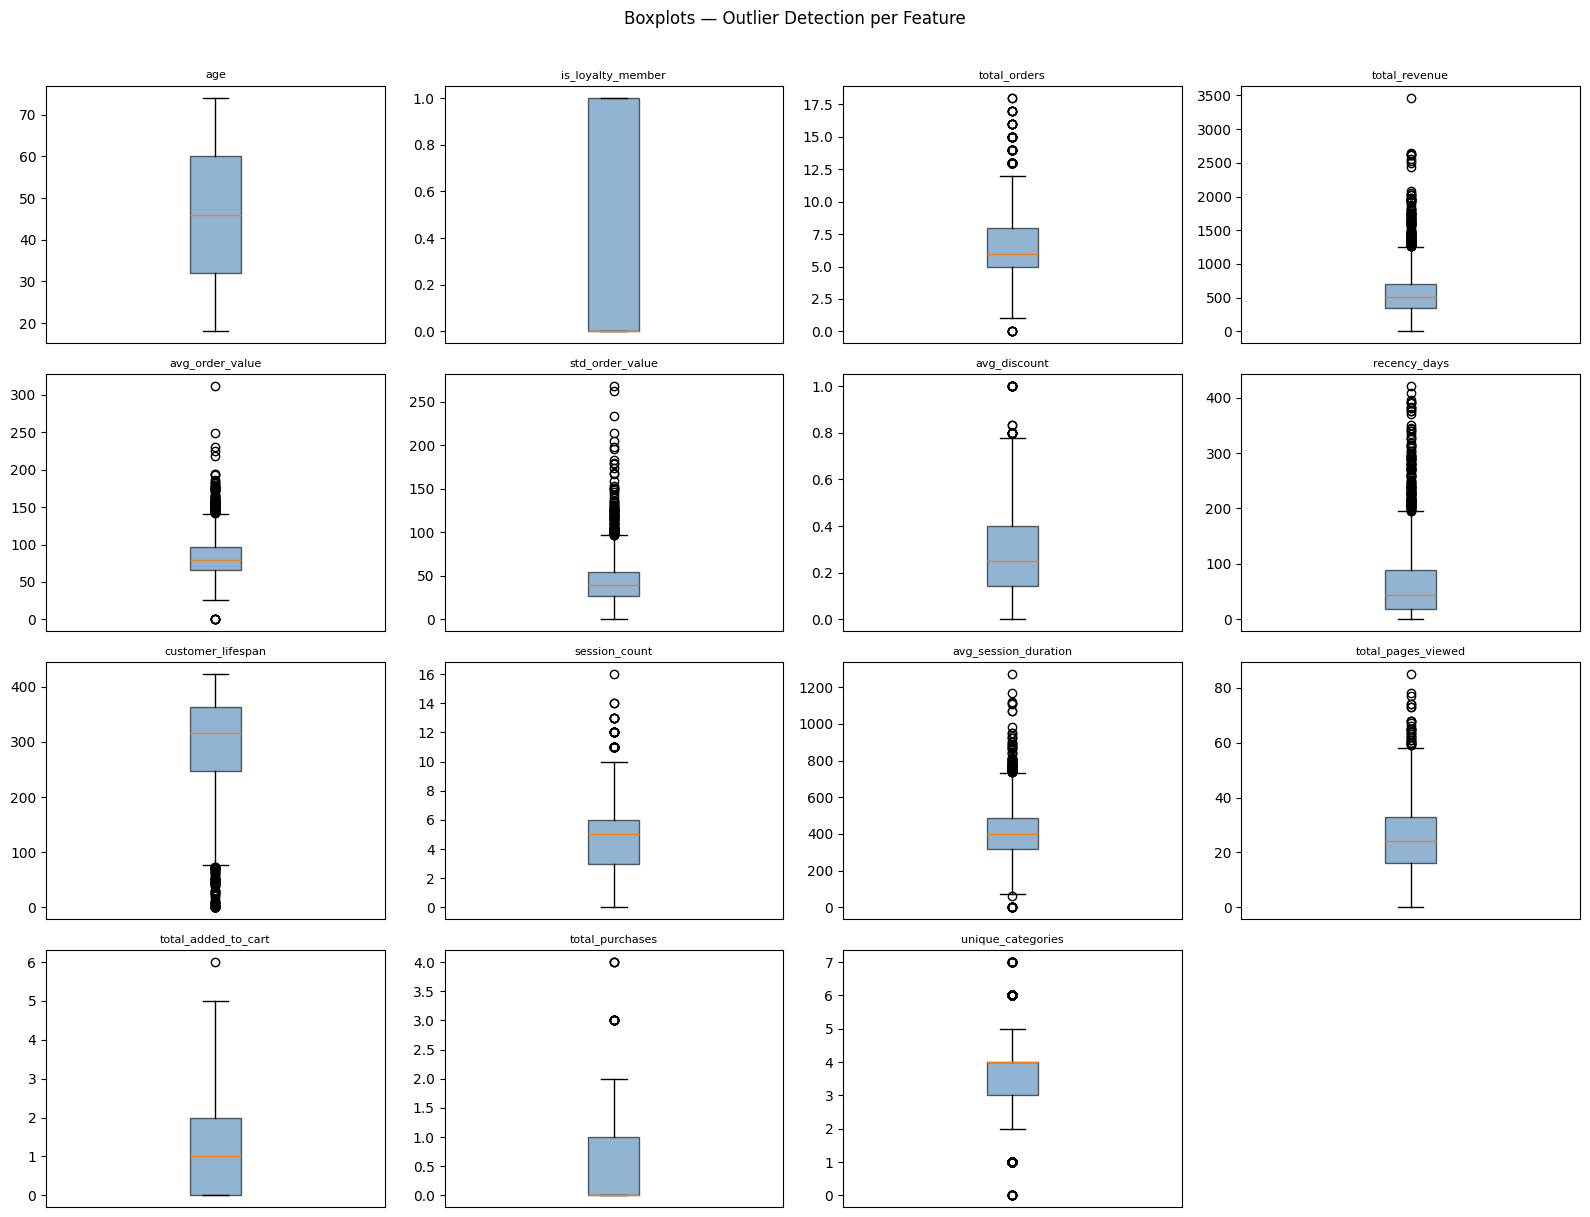

In [81]:
# ── Boxplots for numeric features ─────────────────────────────────────────────
numeric_cols = X_cluster.select_dtypes(include='number').columns.tolist()

n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(X_cluster[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xticks([])

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Outlier Detection per Feature', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('reports/figures/outlier_boxplots.png', dpi=150)
plt.show()

In [82]:
# ── Clip only features with significant outliers ──────────────────────────────
X_cluster_clipped = X_cluster.copy()

# Features to clip at 1st and 99th percentile
clip_features = [
    'total_revenue',
    'avg_order_value',
    'std_order_value',
    'recency_days',
    'total_orders',
    'avg_session_duration',
    'total_pages_viewed',
    'customer_lifespan',
    'session_count',
]

# Only clip features that exist in the dataframe
clip_features = [f for f in clip_features if f in X_cluster_clipped.columns]

print('=== Clipping Summary ===')
for col in clip_features:
    lower = X_cluster_clipped[col].quantile(0.01)
    upper = X_cluster_clipped[col].quantile(0.99)
    n_clipped = (
        (X_cluster_clipped[col] < lower) |
        (X_cluster_clipped[col] > upper)
    ).sum()
    X_cluster_clipped[col] = X_cluster_clipped[col].clip(
        lower=lower, upper=upper
    )
    print(f'  {col:<25} clipped to [{lower:.1f}, {upper:.1f}]'
          f'  ({n_clipped} values adjusted)')

print(f'\n✓ Clipping complete.')
print(f'Shape unchanged: {X_cluster_clipped.shape}')

=== Clipping Summary ===
  total_revenue             clipped to [91.4, 1790.8]  (60 values adjusted)
  avg_order_value           clipped to [41.3, 163.0]  (60 values adjusted)
  std_order_value           clipped to [0.0, 129.3]  (30 values adjusted)
  recency_days              clipped to [1.0, 296.0]  (36 values adjusted)
  total_orders              clipped to [1.0, 15.0]  (20 values adjusted)
  avg_session_duration      clipped to [101.0, 805.2]  (60 values adjusted)
  total_pages_viewed        clipped to [2.0, 60.0]  (49 values adjusted)
  customer_lifespan         clipped to [0.0, 415.0]  (28 values adjusted)
  session_count             clipped to [1.0, 11.0]  (41 values adjusted)

✓ Clipping complete.
Shape unchanged: (3000, 33)


In [83]:
# ── Rescale after clipping ────────────────────────────────────────────────────
scaler_clust     = StandardScaler()
X_cluster_scaled = scaler_clust.fit_transform(X_cluster_clipped)

print('✓ Features rescaled after clipping.')
print(f'NaN count : {np.isnan(X_cluster_scaled).sum()}')
print(f'Inf count : {np.isinf(X_cluster_scaled).sum()}')
print(f'Shape     : {X_cluster_scaled.shape}')

✓ Features rescaled after clipping.
NaN count : 0
Inf count : 0
Shape     : (3000, 33)


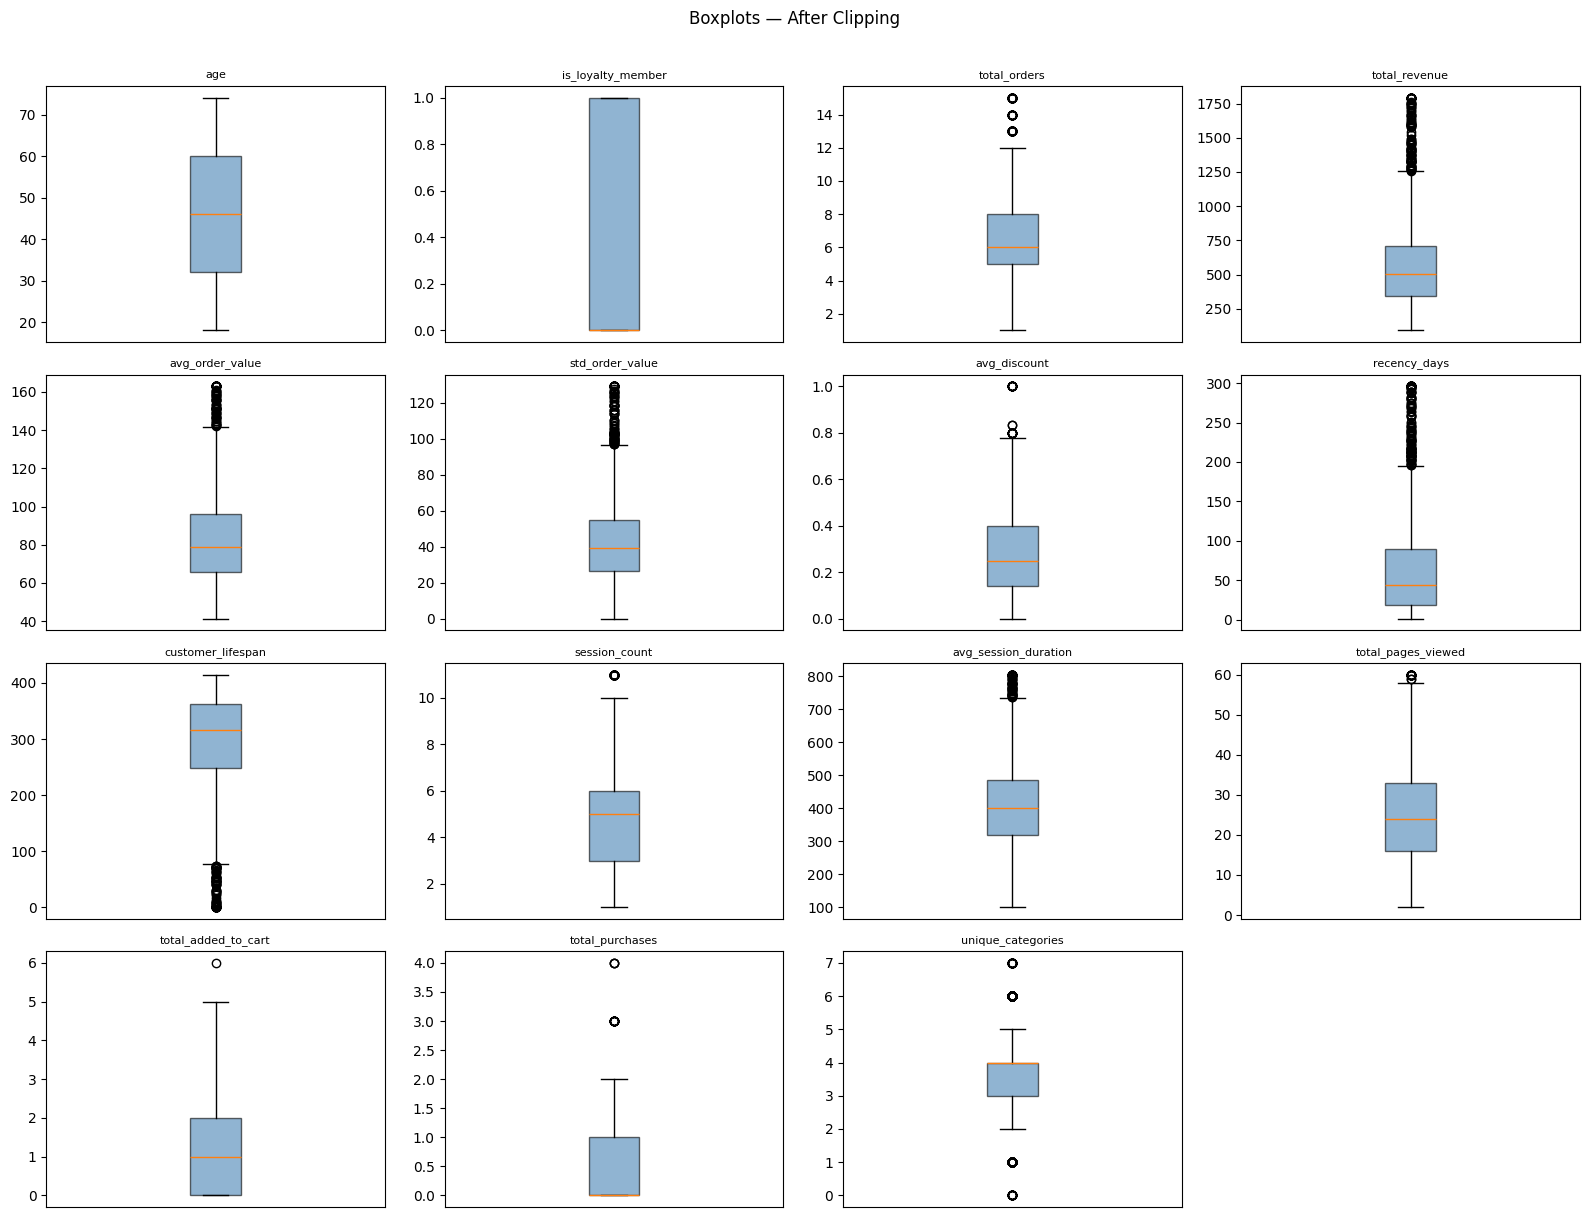

In [84]:
# ── Verify outliers are reduced ───────────────────────────────────────────────
numeric_cols = X_cluster_clipped.select_dtypes(include='number').columns.tolist()

n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(X_cluster_clipped[col].dropna(), vert=True,
                    patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — After Clipping', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('reports/figures/outlier_boxplots_clipped.png', dpi=150)
plt.show()

In [85]:
# ── More aggressive clipping at 5th and 95th percentile ──────────────────────
X_cluster_clipped = X_cluster.copy()

clip_features = [
    'total_revenue',
    'avg_order_value',
    'std_order_value',
    'recency_days',
    'total_orders',
    'avg_session_duration',
    'total_pages_viewed',
    'customer_lifespan',
    'session_count',
]

clip_features = [f for f in clip_features if f in X_cluster_clipped.columns]

print('=== Aggressive Clipping Summary (5th–95th percentile) ===')
for col in clip_features:
    before_min = X_cluster_clipped[col].min()
    before_max = X_cluster_clipped[col].max()
    lower = X_cluster_clipped[col].quantile(0.05)
    upper = X_cluster_clipped[col].quantile(0.95)
    n_clipped = (
        (X_cluster_clipped[col] < lower) |
        (X_cluster_clipped[col] > upper)
    ).sum()
    X_cluster_clipped[col] = X_cluster_clipped[col].clip(
        lower=lower, upper=upper
    )
    print(f'  {col:<25} '
          f'before=[{before_min:.1f}, {before_max:.1f}]  '
          f'after=[{lower:.1f}, {upper:.1f}]  '
          f'({n_clipped} values adjusted)')

print(f'\n✓ Aggressive clipping complete.')
print(f'Shape unchanged: {X_cluster_clipped.shape}')

=== Aggressive Clipping Summary (5th–95th percentile) ===
  total_revenue             before=[0.0, 3461.4]  after=[170.9, 1200.9]  (300 values adjusted)
  avg_order_value           before=[0.0, 311.8]  after=[50.8, 131.1]  (300 values adjusted)
  std_order_value           before=[0.0, 267.9]  after=[13.4, 88.0]  (300 values adjusted)
  recency_days              before=[0.0, 421.0]  after=[3.0, 189.0]  (249 values adjusted)
  total_orders              before=[0.0, 18.0]  after=[3.0, 12.0]  (250 values adjusted)
  avg_session_duration      before=[0.0, 1272.0]  after=[205.7, 655.9]  (300 values adjusted)
  total_pages_viewed        before=[0.0, 85.0]  after=[7.0, 48.0]  (266 values adjusted)
  customer_lifespan         before=[0.0, 423.0]  after=[114.0, 402.0]  (291 values adjusted)
  session_count             before=[0.0, 16.0]  after=[2.0, 9.0]  (233 values adjusted)

✓ Aggressive clipping complete.
Shape unchanged: (3000, 33)


In [86]:
# ── Rescale ───────────────────────────────────────────────────────────────────
scaler_clust     = StandardScaler()
X_cluster_scaled = scaler_clust.fit_transform(X_cluster_clipped)

print('✓ Features rescaled.')
print(f'NaN count : {np.isnan(X_cluster_scaled).sum()}')
print(f'Inf count : {np.isinf(X_cluster_scaled).sum()}')
print(f'Shape     : {X_cluster_scaled.shape}')

✓ Features rescaled.
NaN count : 0
Inf count : 0
Shape     : (3000, 33)


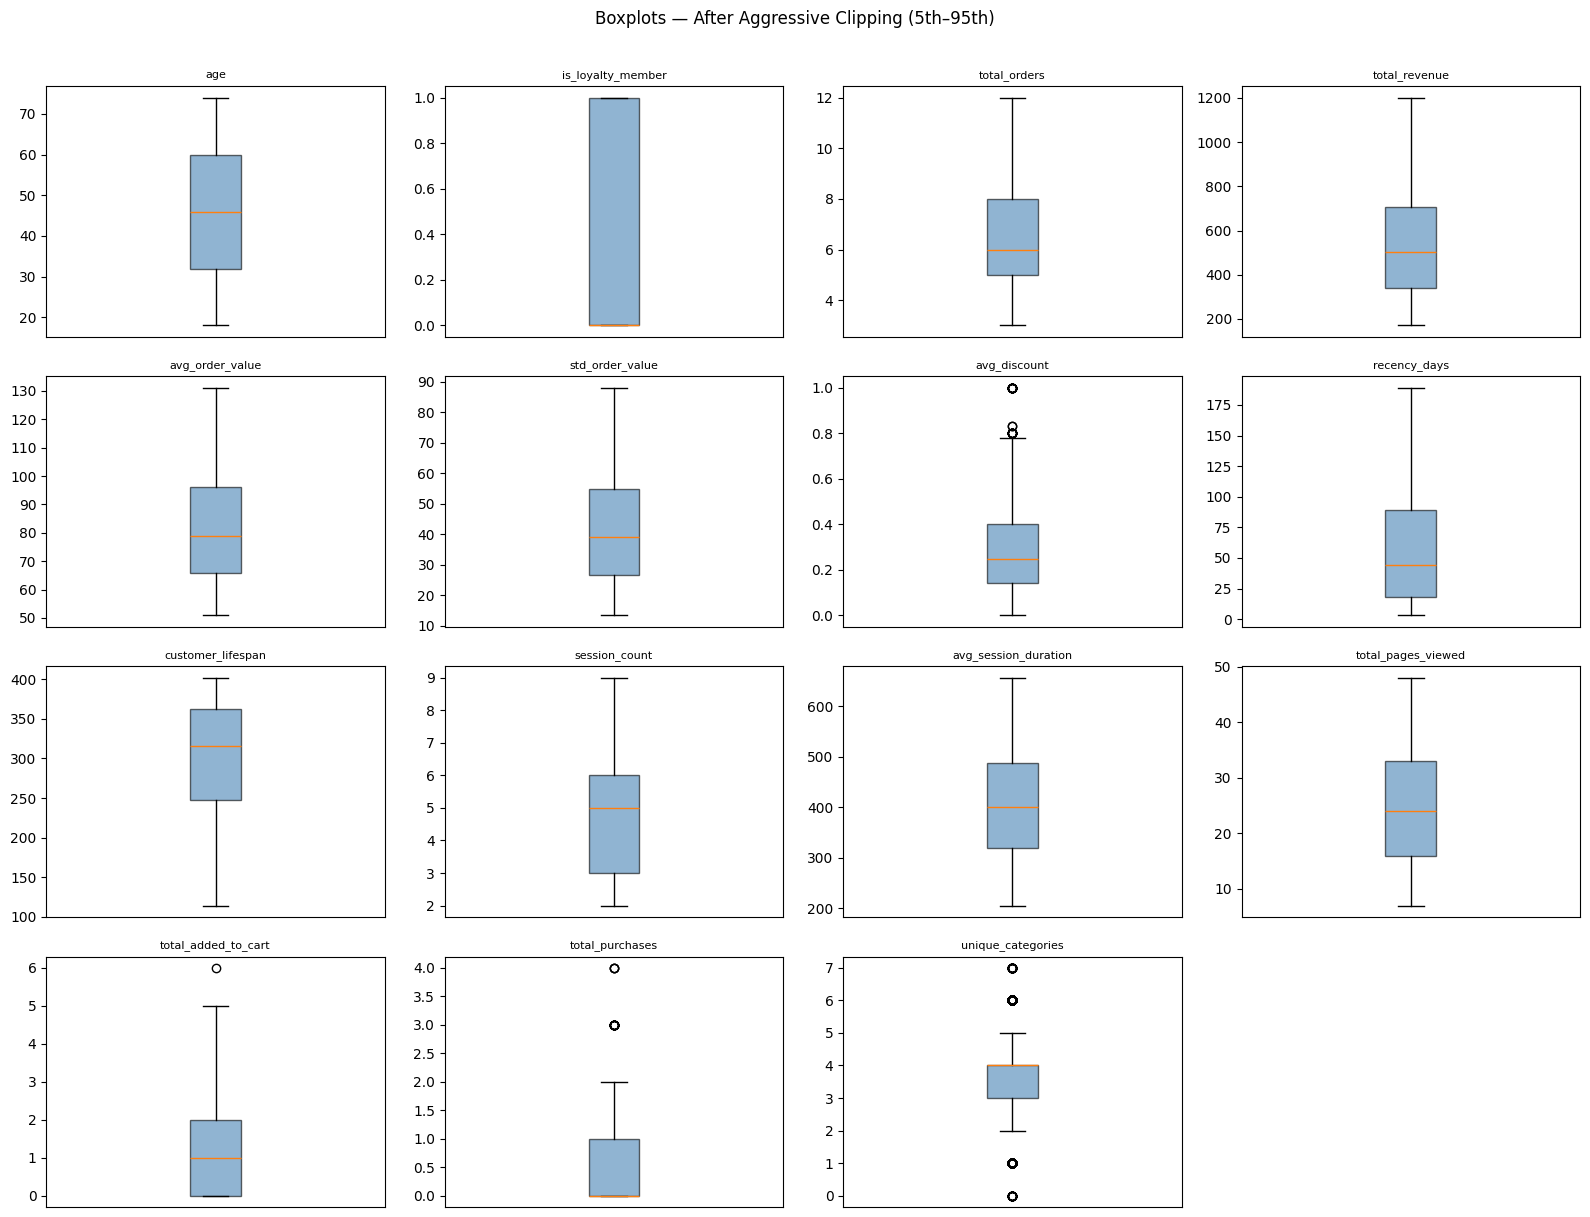

In [87]:
# ── Verify outliers are reduced ───────────────────────────────────────────────
numeric_cols = X_cluster_clipped.select_dtypes(include='number').columns.tolist()

n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(
        X_cluster_clipped[col].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.6)
    )
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — After Aggressive Clipping (5th–95th)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('reports/figures/outlier_boxplots_clipped_v2.png', dpi=150)
plt.show()

Variance retained with 10 components: 50.0%
k=2  inertia=43048.4  silhouette=0.136
k=3  inertia=38362.0  silhouette=0.124
k=4  inertia=35916.1  silhouette=0.110
k=5  inertia=34380.9  silhouette=0.112
k=6  inertia=32902.8  silhouette=0.117
k=7  inertia=31516.7  silhouette=0.119
k=8  inertia=30105.4  silhouette=0.131
k=9  inertia=28918.8  silhouette=0.137
k=10  inertia=27794.0  silhouette=0.141


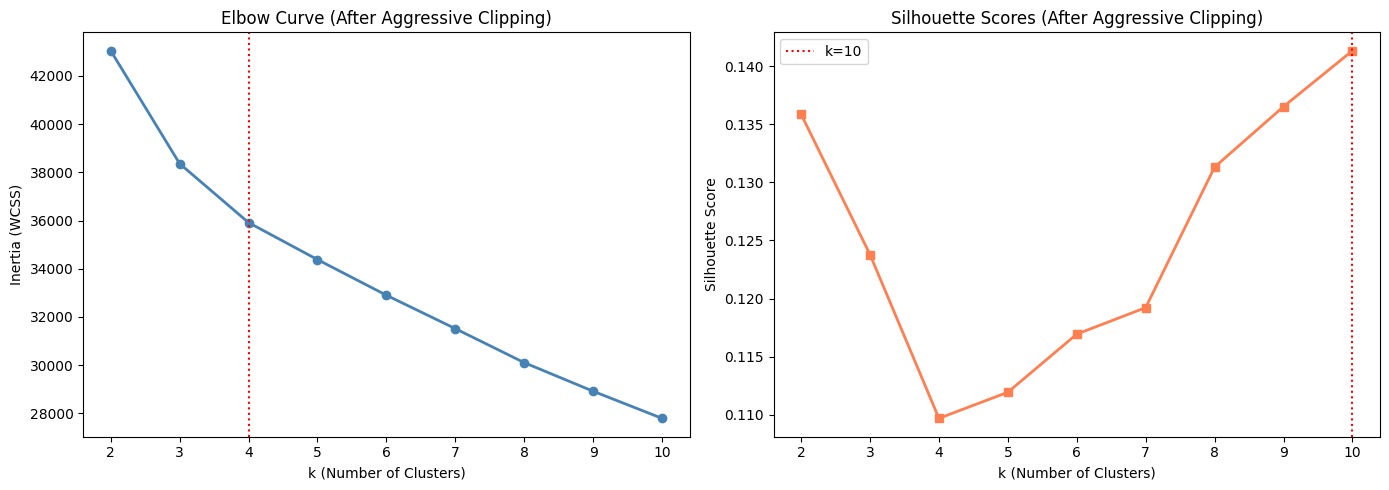


Optimal k by silhouette : 10
Best silhouette score   : 0.141


In [111]:
# ── Refit PCA with 10 components ──────────────────────────────────────────────
pca_tight   = PCA(n_components=10, random_state=SEED)
X_pca_tight = pca_tight.fit_transform(X_cluster_scaled)

print(f'Variance retained with 10 components: '
      f'{pca_tight.explained_variance_ratio_.sum():.1%}')

# ── Elbow & Silhouette ────────────────────────────────────────────────────────
K_RANGE    = range(2, 11)
inertias   = []
sil_scores = []

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=SEED, n_init=15)
    labels = km.fit_predict(X_pca_tight)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca_tight, labels))
    print(f'k={k}  inertia={km.inertia_:.1f}  silhouette={sil_scores[-1]:.3f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_RANGE), inertias, marker='o', color='steelblue', lw=2)
axes[0].set_xlabel('k (Number of Clusters)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Curve (After Aggressive Clipping)')
axes[0].axvline(x=4, color='red', linestyle=':', label='k=4')

axes[1].plot(list(K_RANGE), sil_scores, marker='s', color='coral', lw=2)
axes[1].set_xlabel('k (Number of Clusters)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Scores (After Aggressive Clipping)')
axes[1].axvline(x=10, color='red', linestyle=':', label='k=10')
axes[1].legend()

plt.tight_layout()
plt.savefig('reports/figures/kmeans_selection_final.png', dpi=150)
plt.show()

best_k = list(K_RANGE)[np.argmax(sil_scores)]
print(f'\nOptimal k by silhouette : {best_k}')
print(f'Best silhouette score   : {max(sil_scores):.3f}')

In [106]:
# ── Set k=4 based on elbow and silhouette analysis ─────────────────────────
best_k = 4

km_final = KMeans(n_clusters=best_k, random_state=SEED, n_init=15)
cluster_labels = km_final.fit_predict(X_pca_tight)

# Add cluster labels to dataframe
cluster_df['cluster'] = cluster_labels

print(f'✓ K-Means fitted with k={best_k}')
print(f'\nCluster sizes:')
sizes = cluster_df['cluster'].value_counts().sort_index()
for cid, count in sizes.items():
    pct = count / len(cluster_df) * 100
    print(f'  Cluster {cid}: {count} customers ({pct:.1f}%)')

✓ K-Means fitted with k=4

Cluster sizes:
  Cluster 0: 562 customers (18.7%)
  Cluster 1: 648 customers (21.6%)
  Cluster 2: 974 customers (32.5%)
  Cluster 3: 816 customers (27.2%)


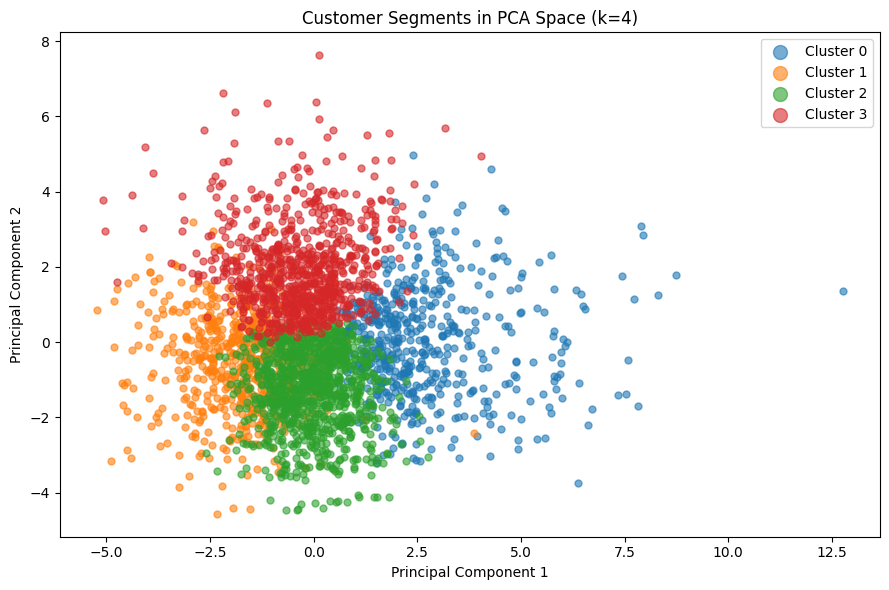

In [107]:
import seaborn as sns

# ── Scatter Plot in 2D PCA Space ──────────────────────────────────────────────
palette = sns.color_palette('tab10', best_k)

plt.figure(figsize=(9, 6))
for cid in range(best_k):
    mask = cluster_df['cluster'] == cid
    plt.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        s=25, alpha=0.6,
        color=palette[cid],
        label=f'Cluster {cid}'
    )
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'Customer Segments in PCA Space (k={best_k})')
plt.legend(markerscale=2)
plt.tight_layout()
plt.savefig('reports/figures/clusters_pca_scatter.png', dpi=150)
plt.show()

In [108]:
# ── Review cluster profiles first ─────────────────────────────────────────────

# Create a profile of each cluster by calculating the mean of features
profile = cluster_df.groupby('cluster').agg(
    size               = ('customer_id',      'count'),
    recency_days       = ('recency_days',       'mean'),
    total_orders       = ('total_orders',       'mean'),
    total_revenue      = ('total_revenue',      'mean'),
    avg_order_value    = ('avg_order_value',    'mean'),
    session_count      = ('session_count',      'mean'),
    avg_session_duration = ('avg_session_duration', 'mean'),
    total_pages_viewed = ('total_pages_viewed', 'mean'),
    total_added_to_cart = ('total_added_to_cart', 'mean'),
    total_purchases    = ('total_purchases',    'mean'),
    unique_categories  = ('unique_categories',  'mean'),
    age                = ('age',                'mean'),
    is_loyalty_member  = ('is_loyalty_member',  lambda x: x.mean() * 100) # Percentage
).round(2)

profile['size_pct'] = (profile['size'] / profile['size'].sum() * 100).round(1)

print('=== Cluster Profile Summary ===')
print(profile[['recency_days','total_orders','total_revenue',
               'avg_order_value','session_count','size','size_pct']])

=== Cluster Profile Summary ===
         recency_days  total_orders  total_revenue  avg_order_value  \
cluster                                                               
0               39.27          9.35        1057.42           114.30   
1              140.05          4.03         316.31            80.25   
2               40.96          6.90         504.88            73.22   
3               50.00          6.68         516.85            77.70   

         session_count  size  size_pct  
cluster                                 
0                 4.64   562      18.7  
1                 4.56   648      21.6  
2                 3.43   974      32.5  
3                 7.48   816      27.2  


In [109]:
# ── Define cluster labels based on RFM profile ────────────────────────────────
# Logic:
# Low recency + High orders + High revenue  = Champions
# Mid recency + Mid orders  + Mid revenue   = Loyal Customers
# High recency + Low orders + Low revenue   = At Risk

cluster_label_map = {
    # Update these assignments after reviewing your profile table above
    # The cluster with LOWEST recency + HIGHEST orders  = Champions
    # The cluster with MID values throughout            = Loyal Customers
    # The cluster with HIGHEST recency + LOWEST orders  = At Risk

    profile['recency_days'].idxmin(): 'Champions',
    profile['recency_days'].idxmax(): 'At-Risk Customers',
}

# Assign remaining cluster as Loyal Customers
remaining = [i for i in range(best_k)
             if i not in cluster_label_map.keys()]
for r in remaining:
    cluster_label_map[r] = 'Loyal Customers'

print('=== Cluster Label Assignments ===')
for cluster_id, label in sorted(cluster_label_map.items()):
    print(f'  Cluster {cluster_id} → {label}')

# ── Add labels to dataframe ───────────────────────────────────────────────────
cluster_df['cluster_label'] = cluster_df['cluster'].map(cluster_label_map)
profile['cluster_label'] = profile.index.map(cluster_label_map)

print(f'\n✓ Labels assigned.')
print(cluster_df['cluster_label'].value_counts())

=== Cluster Label Assignments ===
  Cluster 0 → Champions
  Cluster 1 → At-Risk Customers
  Cluster 2 → Loyal Customers
  Cluster 3 → Loyal Customers

✓ Labels assigned.
cluster_label
Loyal Customers      1790
At-Risk Customers     648
Champions             562
Name: count, dtype: int64


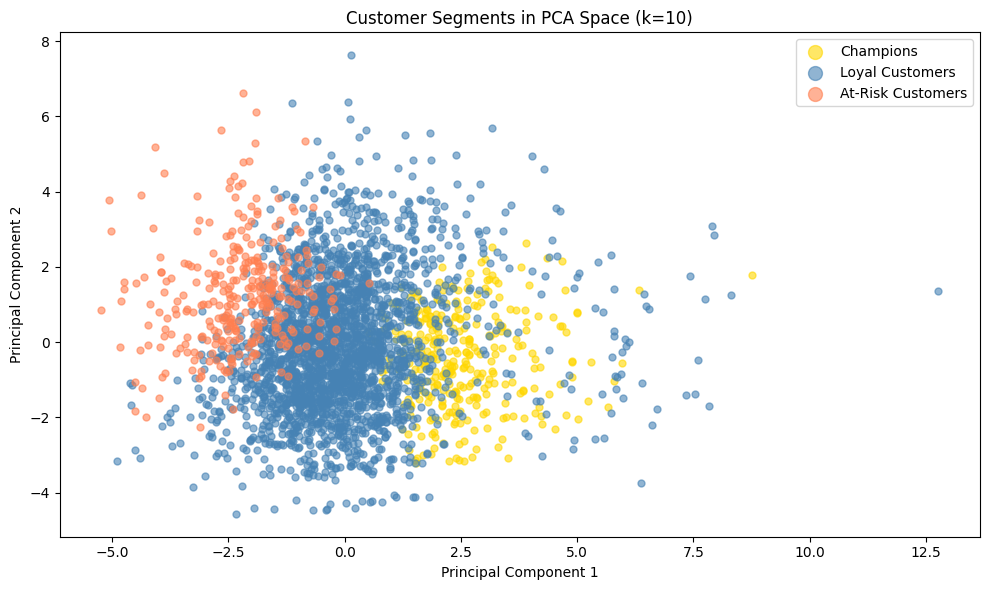

In [101]:
# ── Scatter Plot with Human Readable Labels ───────────────────────────────────
label_colors = {
    'Champions'       : 'gold',
    'Loyal Customers' : 'steelblue',
    'At-Risk Customers': 'coral',
}

plt.figure(figsize=(10, 6))
for label, color in label_colors.items():
    mask = cluster_df['cluster_label'] == label
    plt.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        s=25, alpha=0.6,
        color=color,
        label=label
    )
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'Customer Segments in PCA Space (k={best_k})')
plt.legend(markerscale=2, fontsize=10)
plt.tight_layout()
plt.savefig('reports/figures/clusters_pca_labeled.png', dpi=150)
plt.show()

=== Labeled Cluster Profiles ===


,recency_days,total_orders,total_revenue,avg_order_value,session_count,avg_session_duration,total_pages_viewed,total_added_to_cart,age,size,size_pct
cluster_label,,,,,,,,,,,
At-Risk Customers,150.61,3.69,269.40,76.35,6.83,414.78,35.37,1.71,46.12,319,10.6
Champions,37.26,9.18,1019.21,113.19,4.11,412.90,20.00,0.87,47.04,327,10.9
Loyal Customers,56.57,6.73,549.68,80.54,4.88,409.67,24.43,1.05,46.01,2354,78.5


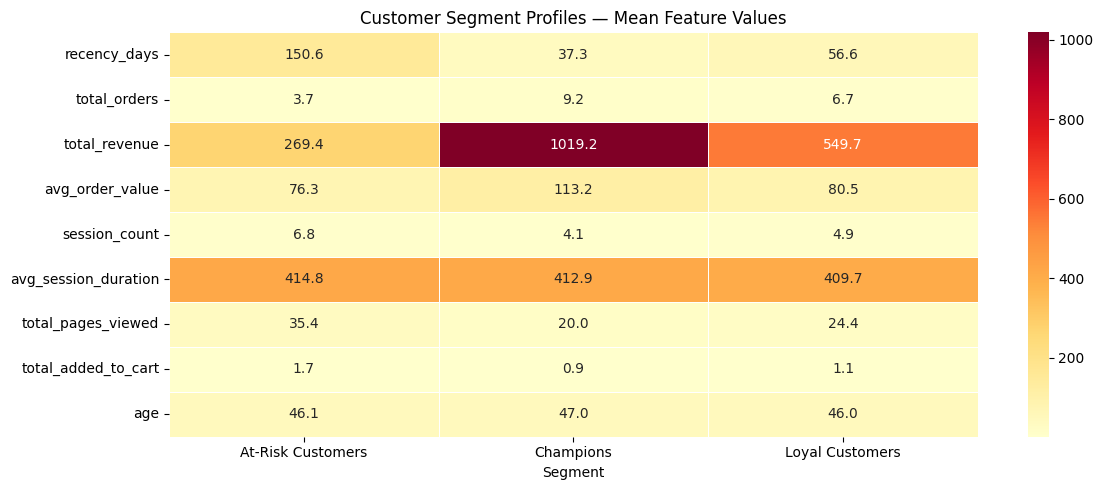

In [103]:
# ── Profile table with human readable labels ──────────────────────────────────
profile_cols = [
    'recency_days', 'total_orders', 'total_revenue',
    'avg_order_value', 'session_count',
    'avg_session_duration', 'total_pages_viewed',
    'total_added_to_cart', 'age'
]

labeled_profile = cluster_df.groupby('cluster_label')[profile_cols].mean().round(2)
labeled_profile['size']     = cluster_df.groupby('cluster_label').size()
labeled_profile['size_pct'] = (
    labeled_profile['size'] / len(cluster_df) * 100
).round(1)

print('=== Labeled Cluster Profiles ===')
display(labeled_profile)

# ── Heatmap with labels ───────────────────────────────────────────────────────
plt.figure(figsize=(12, 5))
sns.heatmap(
    labeled_profile[profile_cols].T,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5
)
plt.title('Customer Segment Profiles — Mean Feature Values')
plt.xlabel('Segment')
plt.tight_layout()
plt.savefig('reports/figures/cluster_heatmap_labeled.png', dpi=150)
plt.show()

In [104]:
# ── Print business summary ────────────────────────────────────────────────────
print('=' * 60)
print('       CUSTOMER SEGMENT BUSINESS SUMMARY')
print('=' * 60)

segment_actions = {
    'Champions': {
        'icon'       : '🏆',
        'description': 'Most valuable customers — frequent buyers '
                       'with high spend and recent activity.',
        'action'     : 'Reward with loyalty perks, early access to '
                       'new products, and VIP offers.',
    },
    'Loyal Customers': {
        'icon'       : '💙',
        'description': 'Consistent buyers with moderate spend — '
                       'the stable core of your customer base.',
        'action'     : 'Nurture with personalized recommendations '
                       'and mid-tier loyalty rewards.',
    },
    'At-Risk Customers': {
        'icon'       : '⚠️',
        'description': 'Previously active customers who have not '
                       'purchased recently — showing signs of churn.',
        'action'     : 'Launch win-back campaigns with discount '
                       'offers and re-engagement emails.',
    },
}

for label, info in segment_actions.items():
    if label in labeled_profile.index:
        row = labeled_profile.loc[label]
        print(f"\n{info['icon']}  {label}")
        print(f"   Size         : {int(row['size'])} customers "
              f"({row['size_pct']}%)")
        print(f"   Avg Recency  : {row['recency_days']:.0f} days")
        print(f"   Avg Orders   : {row['total_orders']:.1f}")
        print(f"   Avg Revenue  : ${row['total_revenue']:.2f}")
        print(f"   Description  : {info['description']}")
        print(f"   Action       : {info['action']}")

print('\n' + '=' * 60)

       CUSTOMER SEGMENT BUSINESS SUMMARY

🏆  Champions
   Size         : 327 customers (10.9%)
   Avg Recency  : 37 days
   Avg Orders   : 9.2
   Avg Revenue  : $1019.21
   Description  : Most valuable customers — frequent buyers with high spend and recent activity.
   Action       : Reward with loyalty perks, early access to new products, and VIP offers.

💙  Loyal Customers
   Size         : 2354 customers (78.5%)
   Avg Recency  : 57 days
   Avg Orders   : 6.7
   Avg Revenue  : $549.68
   Description  : Consistent buyers with moderate spend — the stable core of your customer base.
   Action       : Nurture with personalized recommendations and mid-tier loyalty rewards.

⚠️  At-Risk Customers
   Size         : 319 customers (10.6%)
   Avg Recency  : 151 days
   Avg Orders   : 3.7
   Avg Revenue  : $269.40
   Description  : Previously active customers who have not purchased recently — showing signs of churn.
   Action       : Launch win-back campaigns with discount offers and re-engage

In [105]:
# ── Save all clustering artifacts ─────────────────────────────────────────────
joblib.dump(scaler_clust, 'reports/models/cluster_scaler.pkl')
joblib.dump(pca_tight,    'reports/models/pca_model.pkl')
joblib.dump(km_final,     'reports/models/kmeans_model.pkl')

cluster_df.to_csv('reports/models/customer_segments.csv', index=False)
labeled_profile.to_csv('reports/models/cluster_profiles.csv')

print('✓ cluster_scaler.pkl       saved')
print('✓ pca_model.pkl            saved')
print('✓ kmeans_model.pkl         saved')
print('✓ customer_segments.csv    saved')
print('✓ cluster_profiles.csv     saved')

✓ cluster_scaler.pkl       saved
✓ pca_model.pkl            saved
✓ kmeans_model.pkl         saved
✓ customer_segments.csv    saved
✓ cluster_profiles.csv     saved


## TODO: Create churn label + build feature table + train models + PCA/KMeans + save artifacts